# 1. Data cleaning
* Load data: Import the dataset.
* Handle missing values: Check and handle missing data.
* Identify outliers: Use descriptive statistics and visualization methods to identify outliers.
* Ensure the data type is correct

* Descriptive statistics:
* Calculate basic statistics for each feature (such as mean, standard deviation, minimum, maximum, quartiles, etc.).
* Visualize the data distribution, such as histograms and box plots, to understand the characteristics and distribution of the data (optional)

In [10]:
import chardet

def detect_encoding(file_path):
    with open(file_path, 'rb') as file:
        raw_data = file.read()
        result = chardet.detect(raw_data)
        print(f"Detected encoding for {file_path} is {result['encoding']} with confidence {result['confidence']}")

# 示例使用
detect_encoding('GlobalYouTubeStatistics.csv')

Detected encoding for GlobalYouTubeStatistics.csv is ISO-8859-1 with confidence 0.7289153199558486


## 1.1 View basic data information

In [11]:
import pandas as pd

# 加载数据集
data = pd.read_csv('GlobalYouTubeStatistics.csv',encoding = "ISO-8859-1")
# 查看数据的基本信息
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

## 1.2 Delete meaningless colmns

In [12]:
import numpy as np
# 删除不要的列
# 假设你想删除的列名为'unneeded_column1'和'unneeded_column2'


columns_to_drop = ['Youtuber', 'Title','Abbreviation','category']
# 删除不需要的列
data.drop(columns=columns_to_drop, inplace=True)

In [4]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   subscribers                              995 non-null    int64  
 2   video views                              995 non-null    float64
 3   uploads                                  995 non-null    int64  
 4   Country                                  873 non-null    object 
 5   channel_type                             965 non-null    object 
 6   video_views_rank                         994 non-null    float64
 7   country_rank                             879 non-null    float64
 8   channel_type_rank                        962 non-null    float64
 9   video_views_for_the_last_30_days         939 non-null    float64
 10  lowest_monthly_earnings                  995 non-n

## 1.3 Handling missing values

In [41]:
#Handle missing values
#Fill missing values ​​of categorical features
#Assign NA values ​​for category 1
df= data
df['Country'] = df['Country'].replace(np.nan, "Unknown_Country")
df['channel_type'] = df['channel_type'].replace(np.nan, "Unknown_channelType")

# columns_to_fill is the list including all columns name willing to replace NA with 0
columns_to_fill = ['country_rank', 'Gross tertiary education enrollment (%)', 'Population', 'Unemployment rate', 'Urban_population','Latitude','Longitude']  # 以此类推，添加所有需要处理的列名
for column in columns_to_fill:
    df[column] = df[column].fillna(0.00)
df = df.dropna()

df

,rank,subscribers,video views,uploads,Country,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,245000000,2.280000e+11,20082,India,Music,1.0,1.0,1.0,2.258000e+09,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
2,3,166000000,2.836884e+10,741,United States,Entertainment,48.0,1.0,1.0,1.348000e+09,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,162000000,1.640000e+11,966,United States,Education,2.0,2.0,1.0,1.975000e+09,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,159000000,1.480000e+11,116536,India,Entertainment,3.0,2.0,2.0,1.824000e+09,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
8,9,106000000,9.047906e+10,493,Russia,People,630.0,5.0,25.0,4.894700e+07,...,100000.0,2016.0,Jan,14.0,81.9,1.443735e+08,4.59,107683889.0,61.524010,105.318756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,12300000,9.029610e+09,1200,Brazil,Entertainment,525.0,55.0,172.0,5.525130e+08,...,700000.0,2017.0,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280
991,992,12300000,1.674410e+09,1500,India,Games,6141.0,125.0,69.0,6.473500e+07,...,300000.0,2018.0,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
992,993,12300000,2.214684e+09,2452,United Kingdom,Games,129005.0,867.0,1202.0,6.703500e+04,...,1000.0,2006.0,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994,12300000,3.741235e+08,39,Sweden,Games,35112.0,4.0,69.0,3.871000e+06,...,100000.0,2012.0,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


## 1.4 Create new columns：data[duration]

In [42]:
import pandas as pd
from datetime import datetime

columns_to_check = ['created_month','created_year','created_date']
df = df.dropna(subset=columns_to_check)

# results
df

,rank,subscribers,video views,uploads,Country,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,245000000,2.280000e+11,20082,India,Music,1.0,1.0,1.0,2.258000e+09,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
2,3,166000000,2.836884e+10,741,United States,Entertainment,48.0,1.0,1.0,1.348000e+09,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,162000000,1.640000e+11,966,United States,Education,2.0,2.0,1.0,1.975000e+09,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,159000000,1.480000e+11,116536,India,Entertainment,3.0,2.0,2.0,1.824000e+09,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
8,9,106000000,9.047906e+10,493,Russia,People,630.0,5.0,25.0,4.894700e+07,...,100000.0,2016.0,Jan,14.0,81.9,1.443735e+08,4.59,107683889.0,61.524010,105.318756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,12300000,9.029610e+09,1200,Brazil,Entertainment,525.0,55.0,172.0,5.525130e+08,...,700000.0,2017.0,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280
991,992,12300000,1.674410e+09,1500,India,Games,6141.0,125.0,69.0,6.473500e+07,...,300000.0,2018.0,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
992,993,12300000,2.214684e+09,2452,United Kingdom,Games,129005.0,867.0,1202.0,6.703500e+04,...,1000.0,2006.0,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994,12300000,3.741235e+08,39,Sweden,Games,35112.0,4.0,69.0,3.871000e+06,...,100000.0,2012.0,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


In [43]:
print(df[['created_month','created_date','created_year']].dtypes)
df[['created_month','created_date','created_year']]

created_month     object
created_date     float64
created_year     float64
dtype: object


,created_month,created_date,created_year
0,Mar,13.0,2006.0
2,Feb,20.0,2012.0
3,Sep,1.0,2006.0
4,Sep,20.0,2006.0
8,Jan,14.0,2016.0
...,...,...,...
990,Feb,12.0,2017.0
991,Sep,14.0,2018.0
992,Sep,11.0,2006.0
993,May,9.0,2012.0


In [44]:
import pandas as pd

# Sample data (replace with your actual DataFrame)

#Ensure created_date is an integer
df['created_date'] = data['created_date'].astype(int)
df['created_year'] = data['created_year'].astype(int)
print(df['created_date'])
print(df['created_year'])

0      13
2      20
3       1
4      20
8      14
       ..
990    12
991    14
992    11
993     9
994     1
Name: created_date, Length: 637, dtype: int32
0      2006
2      2012
3      2006
4      2006
8      2016
       ... 
990    2017
991    2018
992    2006
993    2012
994    2017
Name: created_year, Length: 637, dtype: int32


In [45]:
# Create a properly formatted date string
df['date_string'] = df.apply(lambda row: f"{row['created_year']}-{row['created_month']}-{row['created_date']}", axis=1)
print(df['date_string'])

0      2006-Mar-13
2      2012-Feb-20
3       2006-Sep-1
4      2006-Sep-20
8      2016-Jan-14
          ...     
990    2017-Feb-12
991    2018-Sep-14
992    2006-Sep-11
993     2012-May-9
994     2017-Aug-1
Name: date_string, Length: 637, dtype: object


In [46]:
# Convert to datetime, handling errors
df['created_date'] = pd.to_datetime(df['date_string'], format='%Y-%b-%d', errors='coerce')

# Calculate the time difference
target_date = pd.to_datetime('2023-09-15')
df['duration'] = (target_date - df['created_date']).dt.days

print(df['created_date'])

0     2006-03-13
2     2012-02-20
3     2006-09-01
4     2006-09-20
8     2016-01-14
         ...    
990   2017-02-12
991   2018-09-14
992   2006-09-11
993   2012-05-09
994   2017-08-01
Name: created_date, Length: 637, dtype: datetime64[ns]


In [47]:
#check duplication
print("重复值数量:", df.duplicated().sum()) 
df.drop_duplicates(inplace=True)  # delete

重复值数量: 0


# 1.5  Shrinking processing

In [48]:
# Shrinking processing
# Define the shrinking processing function to skip the places where the element is 0
def winsorize_series(series, lower_quantile=0.02, upper_quantile=0.98): 
    lower_limit = series[series != 0].quantile(lower_quantile) 
    upper_limit = series[series != 0].quantile(upper_quantile) 
    return np.where(series == 0, 0, np.where(series < lower_limit, lower_limit, np.where(series > upper_limit, upper_limit, series))) # 指定需要缩尾处理的列 columns_to_winsorize = ['value1', 'value2'] # 对指定的列进行缩尾处理 

columns_to_winsorize=['video views', 'uploads', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings','highest_yearly_earnings','Gross tertiary education enrollment (%)', 'Population','Unemployment rate', 'Urban_population']
df[columns_to_winsorize] = df[columns_to_winsorize].apply(winsorize_series) 
df

,rank,subscribers,video views,uploads,Country,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,...,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude,date_string,duration
0,1,245000000,5.552559e+10,20082.0,India,Music,1.0,1.0,1.0,1.608360e+09,...,Mar,2006-03-13,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-Mar-13,6395
2,3,166000000,2.836884e+10,741.0,United States,Entertainment,48.0,1.0,1.0,1.348000e+09,...,Feb,2012-02-20,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2012-Feb-20,4225
3,4,162000000,5.552559e+10,966.0,United States,Education,2.0,2.0,1.0,1.608360e+09,...,Sep,2006-09-01,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-Sep-1,6223
4,5,159000000,5.552559e+10,116536.0,India,Entertainment,3.0,2.0,2.0,1.608360e+09,...,Sep,2006-09-20,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-Sep-20,6204
8,9,106000000,5.552559e+10,493.0,Russia,People,630.0,5.0,25.0,4.894700e+07,...,Jan,2016-01-14,81.9,1.443735e+08,4.59,107683889.0,61.524010,105.318756,2016-Jan-14,2801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,12300000,9.029610e+09,1200.0,Brazil,Entertainment,525.0,55.0,172.0,5.525130e+08,...,Feb,2017-02-12,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280,2017-Feb-12,2406
991,992,12300000,1.674410e+09,1500.0,India,Games,6141.0,125.0,69.0,6.473500e+07,...,Sep,2018-09-14,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2018-Sep-14,1827
992,993,12300000,2.214684e+09,2452.0,United Kingdom,Games,129005.0,867.0,1202.0,6.703500e+04,...,Sep,2006-09-11,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973,2006-Sep-11,6213
993,994,12300000,1.019436e+09,39.0,Sweden,Games,35112.0,4.0,69.0,3.871000e+06,...,May,2012-05-09,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501,2012-May-9,4146


In [49]:
df.columns

Index(['rank', 'subscribers', 'video views', 'uploads', 'Country',
       'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude',
       'date_string', 'duration'],
      dtype='object')

# 1.6 Rename columns

In [51]:
old_columns = ['rank', 'subscribers', 'video views', 'uploads', 'Country',
       'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude',
       'date_string', 'duration']

new_columns = [
    'rank',
    'subscribers',
    'video_views',
    'uploads',
    'country',
    'channel_type',
    'video_views_rank',
    'country_rank',
    'channel_type_rank',
    'video_views_30_days',
    'lowest_monthly_earnings',
    'highest_monthly_earnings',
    'lowest_yearly_earnings',
    'highest_yearly_earnings',
    'subscribers_30_days',
    'creation_year',
    'creation_month',
    'creation_date',
    'tertiary_education_enrollment_rate',
    'population',
    'unemployment_rate',
    'urban_population',
    'latitude',
    'longitude',
    'date_string',
    'duration_days'
]

# Create the renaming dictionary using zip
rename_dict = dict(zip(old_columns, new_columns))

# Rename the columns
df = df.rename(columns=rename_dict)
df

,rank,subscribers,video_views,uploads,country,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_30_days,...,creation_month,creation_date,tertiary_education_enrollment_rate,population,unemployment_rate,urban_population,latitude,longitude,date_string,duration_days
0,1,245000000,5.552559e+10,20082.0,India,Music,1.0,1.0,1.0,1.608360e+09,...,Mar,2006-03-13,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-Mar-13,6395
2,3,166000000,2.836884e+10,741.0,United States,Entertainment,48.0,1.0,1.0,1.348000e+09,...,Feb,2012-02-20,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2012-Feb-20,4225
3,4,162000000,5.552559e+10,966.0,United States,Education,2.0,2.0,1.0,1.608360e+09,...,Sep,2006-09-01,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-Sep-1,6223
4,5,159000000,5.552559e+10,116536.0,India,Entertainment,3.0,2.0,2.0,1.608360e+09,...,Sep,2006-09-20,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-Sep-20,6204
8,9,106000000,5.552559e+10,493.0,Russia,People,630.0,5.0,25.0,4.894700e+07,...,Jan,2016-01-14,81.9,1.443735e+08,4.59,107683889.0,61.524010,105.318756,2016-Jan-14,2801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,12300000,9.029610e+09,1200.0,Brazil,Entertainment,525.0,55.0,172.0,5.525130e+08,...,Feb,2017-02-12,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280,2017-Feb-12,2406
991,992,12300000,1.674410e+09,1500.0,India,Games,6141.0,125.0,69.0,6.473500e+07,...,Sep,2018-09-14,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2018-Sep-14,1827
992,993,12300000,2.214684e+09,2452.0,United Kingdom,Games,129005.0,867.0,1202.0,6.703500e+04,...,Sep,2006-09-11,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973,2006-Sep-11,6213
993,994,12300000,1.019436e+09,39.0,Sweden,Games,35112.0,4.0,69.0,3.871000e+06,...,May,2012-05-09,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501,2012-May-9,4146


# 1.7 Check the cleaned data and Descriptive Statisticss

In [52]:
print("清洗后的数据概况:\n", df.info())
print("缺失值:\n", df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 0 to 994
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   rank                                637 non-null    int64         
 1   subscribers                         637 non-null    int64         
 2   video_views                         637 non-null    float64       
 3   uploads                             637 non-null    float64       
 4   country                             637 non-null    object        
 5   channel_type                        637 non-null    object        
 6   video_views_rank                    637 non-null    float64       
 7   country_rank                        637 non-null    float64       
 8   channel_type_rank                   637 non-null    float64       
 9   video_views_30_days                 637 non-null    float64       
 10  lowest_monthly_earnings        

In [53]:
#Descriptive Statistics
#Compute basic statistics using Pandas
stats = df.describe() 
print(stats)


             rank   subscribers   video_views        uploads  \
count  637.000000  6.370000e+02  6.370000e+02     637.000000   
mean   468.021978  2.409560e+07  1.179769e+10   11726.125589   
min      1.000000  1.230000e+07  1.019436e+09       5.000000   
25%    215.000000  1.470000e+07  4.935793e+09     398.000000   
50%    449.000000  1.880000e+07  8.826138e+09    1024.000000   
75%    719.000000  2.620000e+07  1.506575e+10    3716.000000   
max    995.000000  2.450000e+08  5.552559e+10  180834.000000   
std    288.727265  1.844200e+07  1.045425e+10   34407.406084   

       video_views_rank  country_rank  channel_type_rank  video_views_30_days  \
count      6.370000e+02    637.000000         637.000000         6.370000e+02   
mean       2.051641e+05    170.857143         357.711146         2.186808e+08   
min        1.000000e+00      0.000000           1.000000         8.572000e+01   
25%        2.330000e+02      7.000000          20.000000         4.648400e+07   
50%        6.08000

## 1.8 Output the cleaned dataset

In [5]:
import pandas as pd

# Specify the output file name
output_filename = 'cleaned_youtube_data.csv'

# Write the DataFrame to a CSV file.  index=False prevents writing the DataFrame index.
df.to_csv(output_filename, index=False)

print(f"Cleaned data saved to {output_filename}")

Cleaned data saved to cleaned_youtube_data.csv


In [6]:
# EDA analysis
import numpy as np
import pandas as pd

df = pd.read_csv("cleaned_youtube_data.csv")
df.head()

,rank,subscribers,video_views,uploads,country,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_30_days,...,creation_month,creation_date,tertiary_education_enrollment_rate,population,unemployment_rate,urban_population,latitude,longitude,date_string,duration_days
0,1,245000000,5.552559e+10,20082.0,India,Music,1.0,1.0,1.0,1.608360e+09,...,Mar,2006-03-13,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-Mar-13,6395
1,3,166000000,2.836884e+10,741.0,United States,Entertainment,48.0,1.0,1.0,1.348000e+09,...,Feb,2012-02-20,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2012-Feb-20,4225
2,4,162000000,5.552559e+10,966.0,United States,Education,2.0,2.0,1.0,1.608360e+09,...,Sep,2006-09-01,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-Sep-1,6223
3,5,159000000,5.552559e+10,116536.0,India,Entertainment,3.0,2.0,2.0,1.608360e+09,...,Sep,2006-09-20,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-Sep-20,6204
4,9,106000000,5.552559e+10,493.0,Russia,People,630.0,5.0,25.0,4.894700e+07,...,Jan,2016-01-14,81.9,1.443735e+08,4.59,107683889.0,61.524010,105.318756,2016-Jan-14,2801


In [14]:
subscribers = df['subscribers']
bin_width = 100 # change to 10, 20, 40, 100
bins = np.arange(min(subscribers), max(subscribers) + bin_width, bin_width)
df_subscriber
bins

array([ 12300000,  12300100,  12300200, ..., 244999800, 244999900,
       245000000])

KeyboardInterrupt: 

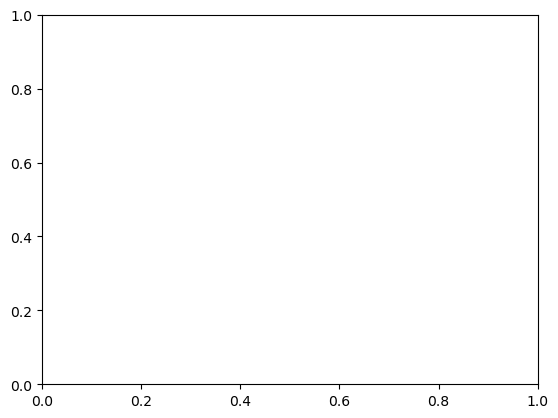

In [15]:
import matplotlib.pyplot as plt
plt.hist(subscribers, bins=bins)
plt.xlabel('Subscribers')
plt.ylabel('Frequency')
plt.title('Subscriber Histogram')
plt.show()